# Pose Trajectory T-CFM Evaluation

Load a trained model checkpoint, generate trajectories conditioned on context vectors, and visualize results.

In [3]:
import os, sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# make sure project root is on path
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ""))
sys.path.insert(0, os.getcwd())
os.chdir(os.path.expanduser("~/PhysicalAI_flowmatching"))

import diffuser.utils as utils

## 1. Configuration

Set the checkpoint path and device. Update `CHECKPOINT_PATH` to point to your trained model.

In [4]:
# --- UPDATE THIS ---
CHECKPOINT_PATH = "logs/pose_trajectory_athitv2/cfm/H64_T100/20260415-1830/state_192000.pt"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_PATH = "data/pose_traject_dataset_athitv2.npz"

HORIZON = 64        # padded horizon (must match training)
ORIGINAL_LEN = 50   # original trajectory length
N_SAMPLING_STEPS = 100  # Euler sampling steps for CFM

## 2. Load Dataset

In [5]:
data = np.load(DATA_PATH) # load dataset (limit to 1M samples for memory)
df = pd.DataFrame(data['features'], columns=data['feature_names'])[:1000000] 
df['targets'] = [t for t in data['targets'][:1000000]]

# Context vector C (9-dim)
part_onehot = pd.get_dummies(df['part_enum'].astype(int), prefix='part').values
C = np.concatenate([
    df[['s_goal_x', 
        's_goal_y', 
        's_goal_z', # qdot_init_x
        'q_init_z', # qdot_init_y
        'v_const', 
        'accel']].values,
    part_onehot,
    df[['q_init_x', 'q_init_y']].values
], axis=1)

# Ground truth trajectories (x, y)
targets_raw = np.stack(df['targets'].values)
A_gt = targets_raw[:, :, 0:2]  # (N, 50, 2)

context_all = torch.tensor(C, dtype=torch.float32)
print(f"Dataset: {len(df)} samples, context_dim={C.shape[1]}, trajectory=({A_gt.shape[1]}, {A_gt.shape[2]})")

Dataset: 1000000 samples, context_dim=12, trajectory=(50, 2)


## 3. Build Model & Load Checkpoint

In [6]:
from diffuser.models.temporal_film import ConditionalUnet1D
from diffuser.models.cfm import CFM

observation_dim = 2
action_dim = 0
context_dim = C.shape[1]  # 9

# Build model (must match training config)
model = ConditionalUnet1D(
    horizon=HORIZON,
    transition_dim=observation_dim + action_dim,
    lstm_in_dim=None,
    lstm_out_dim=None,
    global_cond_dim=context_dim,
    cond_dim=observation_dim,
    dim_mults=(1, 4, 8),
).to(DEVICE)

# Build diffusion wrapper
diffusion = CFM(
    model=model,
    horizon=HORIZON,
    observation_dim=observation_dim,
    action_dim=action_dim,
    n_timesteps=N_SAMPLING_STEPS,
    loss_type='l2',
    predict_epsilon=False,
).to(DEVICE)

# Load checkpoint
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
diffusion.load_state_dict(checkpoint['model'])
print(f"Loaded checkpoint from step {checkpoint['step']}")

Loaded checkpoint from step 195000


## 4. Sampling Helper

In [7]:
@torch.no_grad()
def sample_trajectories(diffusion, contexts, n_samples_per=1):
    """
    Generate trajectories for given context vectors.
    
    Args:
        diffusion: trained CFM model
        contexts: (B, 9) context tensor
        n_samples_per: how many samples to generate per context
    Returns:
        samples: (B * n_samples_per, ORIGINAL_LEN, 2) numpy array
        contexts_repeated: (B * n_samples_per, 9) numpy array
    """
    diffusion.eval()
    
    # repeat contexts for multiple samples
    ctx = contexts.repeat_interleave(n_samples_per, dim=0).to(DEVICE)
    batch_size = ctx.shape[0]
    
    global_cond = {'hideouts': ctx}
    cond = [(np.array([]), np.array([]))] * batch_size
    
    samples = diffusion.conditional_sample(global_cond, cond)  # (B*n, HORIZON, 2)
    samples = samples.cpu().numpy()
    
    # trim padding back to original 50 steps
    samples = samples[:, :ORIGINAL_LEN, :]
    contexts_out = ctx.cpu().numpy()
    
    return samples, contexts_out

print("Sampling helper ready.")

Sampling helper ready.


## 5. Generate Samples & Compute Metrics

Evaluated 200 contexts x 1 samples each
Metric                Mean        Std     Median
-----------------------------------------------
ADE (best)          0.1181     0.3490     0.0392
ADE (avg)           0.1181     0.3490     0.0392
FDE (best)          0.1483     0.4164     0.0435
FDE (avg)           0.1483     0.4164     0.0435


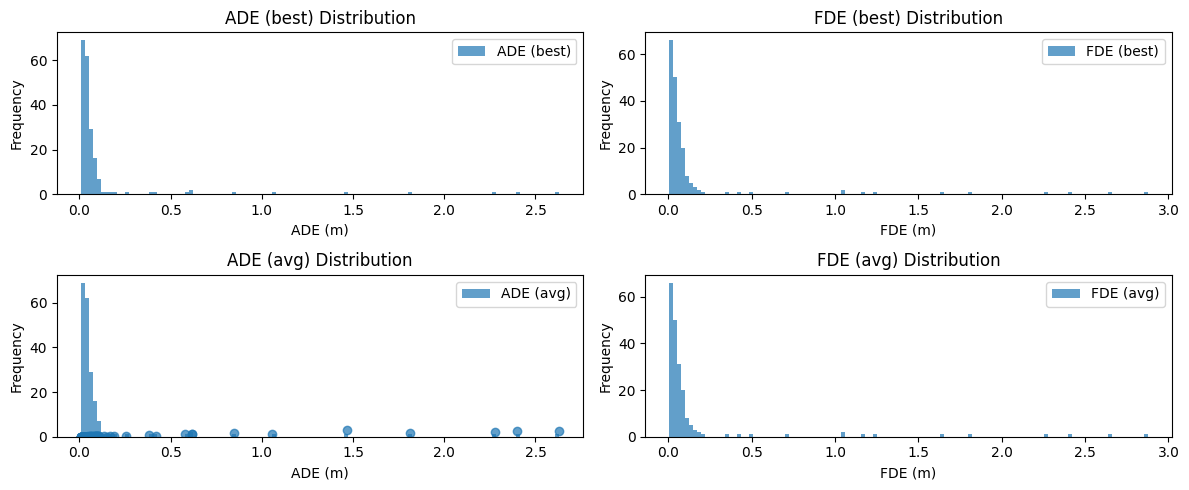

In [8]:
# Pick test samples to evaluate
N_EVAL = 200          # how many test contexts to use
# N_SAMPLES_PER = 5     # how many trajectories to sample per context
N_SAMPLES_PER = 1     # how many trajectories to sample per context

rng = np.random.default_rng(42)
eval_idx = rng.choice(len(context_all), N_EVAL, replace=False)

eval_contexts = context_all[eval_idx]
eval_gt = A_gt[eval_idx]  # (N_EVAL, 50, 2)

# Generate
samples, _ = sample_trajectories(diffusion, eval_contexts, n_samples_per=N_SAMPLES_PER)
samples = samples.reshape(N_EVAL, N_SAMPLES_PER, ORIGINAL_LEN, 2)

# --- ADE (Average Displacement Error) ---
# per-sample ADE: mean L2 distance over all timesteps
ade_per_sample = np.sqrt(((samples - eval_gt[:, None, :, :]) ** 2).sum(axis=-1)).mean(axis=-1)  # (N_EVAL, N_SAMPLES_PER)
ade_min = ade_per_sample.min(axis=1)    # best-of-N
ade_mean = ade_per_sample.mean(axis=1)  # average-of-N

# --- FDE (Final Displacement Error) ---
fde_per_sample = np.sqrt(((samples[:, :, -1, :] - eval_gt[:, None, -1, :]) ** 2).sum(axis=-1))  # (N_EVAL, N_SAMPLES_PER)
fde_min = fde_per_sample.min(axis=1)
fde_mean = fde_per_sample.mean(axis=1)

print(f"Evaluated {N_EVAL} contexts x {N_SAMPLES_PER} samples each")
print(f"{'Metric':<15} {'Mean':>10} {'Std':>10} {'Median':>10}")
print("-" * 47)
print(f"{'ADE (best)':<15} {ade_min.mean():>10.4f} {ade_min.std():>10.4f} {np.median(ade_min):>10.4f}")
print(f"{'ADE (avg)':<15} {ade_mean.mean():>10.4f} {ade_mean.std():>10.4f} {np.median(ade_mean):>10.4f}")
print(f"{'FDE (best)':<15} {fde_min.mean():>10.4f} {fde_min.std():>10.4f} {np.median(fde_min):>10.4f}")
print(f"{'FDE (avg)':<15} {fde_mean.mean():>10.4f} {fde_mean.std():>10.4f} {np.median(fde_mean):>10.4f}")

# plot distribution of errors
plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 1)
plt.hist(ade_min, bins=120, alpha=0.7, label='ADE (best)')
# plt.hist(ade_mean, bins=120, alpha=0.7, label='ADE (avg)')
plt.xlabel('ADE (m)')
plt.ylabel('Frequency')
plt.title('ADE (best) Distribution')
plt.legend()

plt.subplot(2, 2, 2)
plt.hist(fde_min, bins=120, alpha=0.7, label='FDE (best)')
# plt.hist(fde_mean, bins=120, alpha=0.7, label='FDE (avg)')
plt.xlabel('FDE (m)')
plt.ylabel('Frequency')
plt.title('FDE (best) Distribution')
plt.legend()

plt.subplot(2, 2, 3)
plt.scatter(ade_min, fde_min, alpha=0.7)
# plt.hist(ade_min, bins=120, alpha=0.7, label='ADE (best)')
plt.hist(ade_mean, bins=120, alpha=0.7, label='ADE (avg)')
plt.xlabel('ADE (m)')
plt.ylabel('Frequency')
plt.title('ADE (avg) Distribution')
plt.legend()

plt.subplot(2, 2, 4)
# plt.hist(fde_min, bins=120, alpha=0.7, label='FDE (best)')
plt.hist(fde_mean, bins=120, alpha=0.7, label='FDE (avg)')
plt.xlabel('FDE (m)')
plt.ylabel('Frequency')
plt.title('FDE (avg) Distribution')
plt.legend()

plt.tight_layout()
plt.show()

## 6. Plot: Generated vs Ground Truth Trajectories

Each subplot shows one test context. The ground truth is in black, and generated samples are colored.

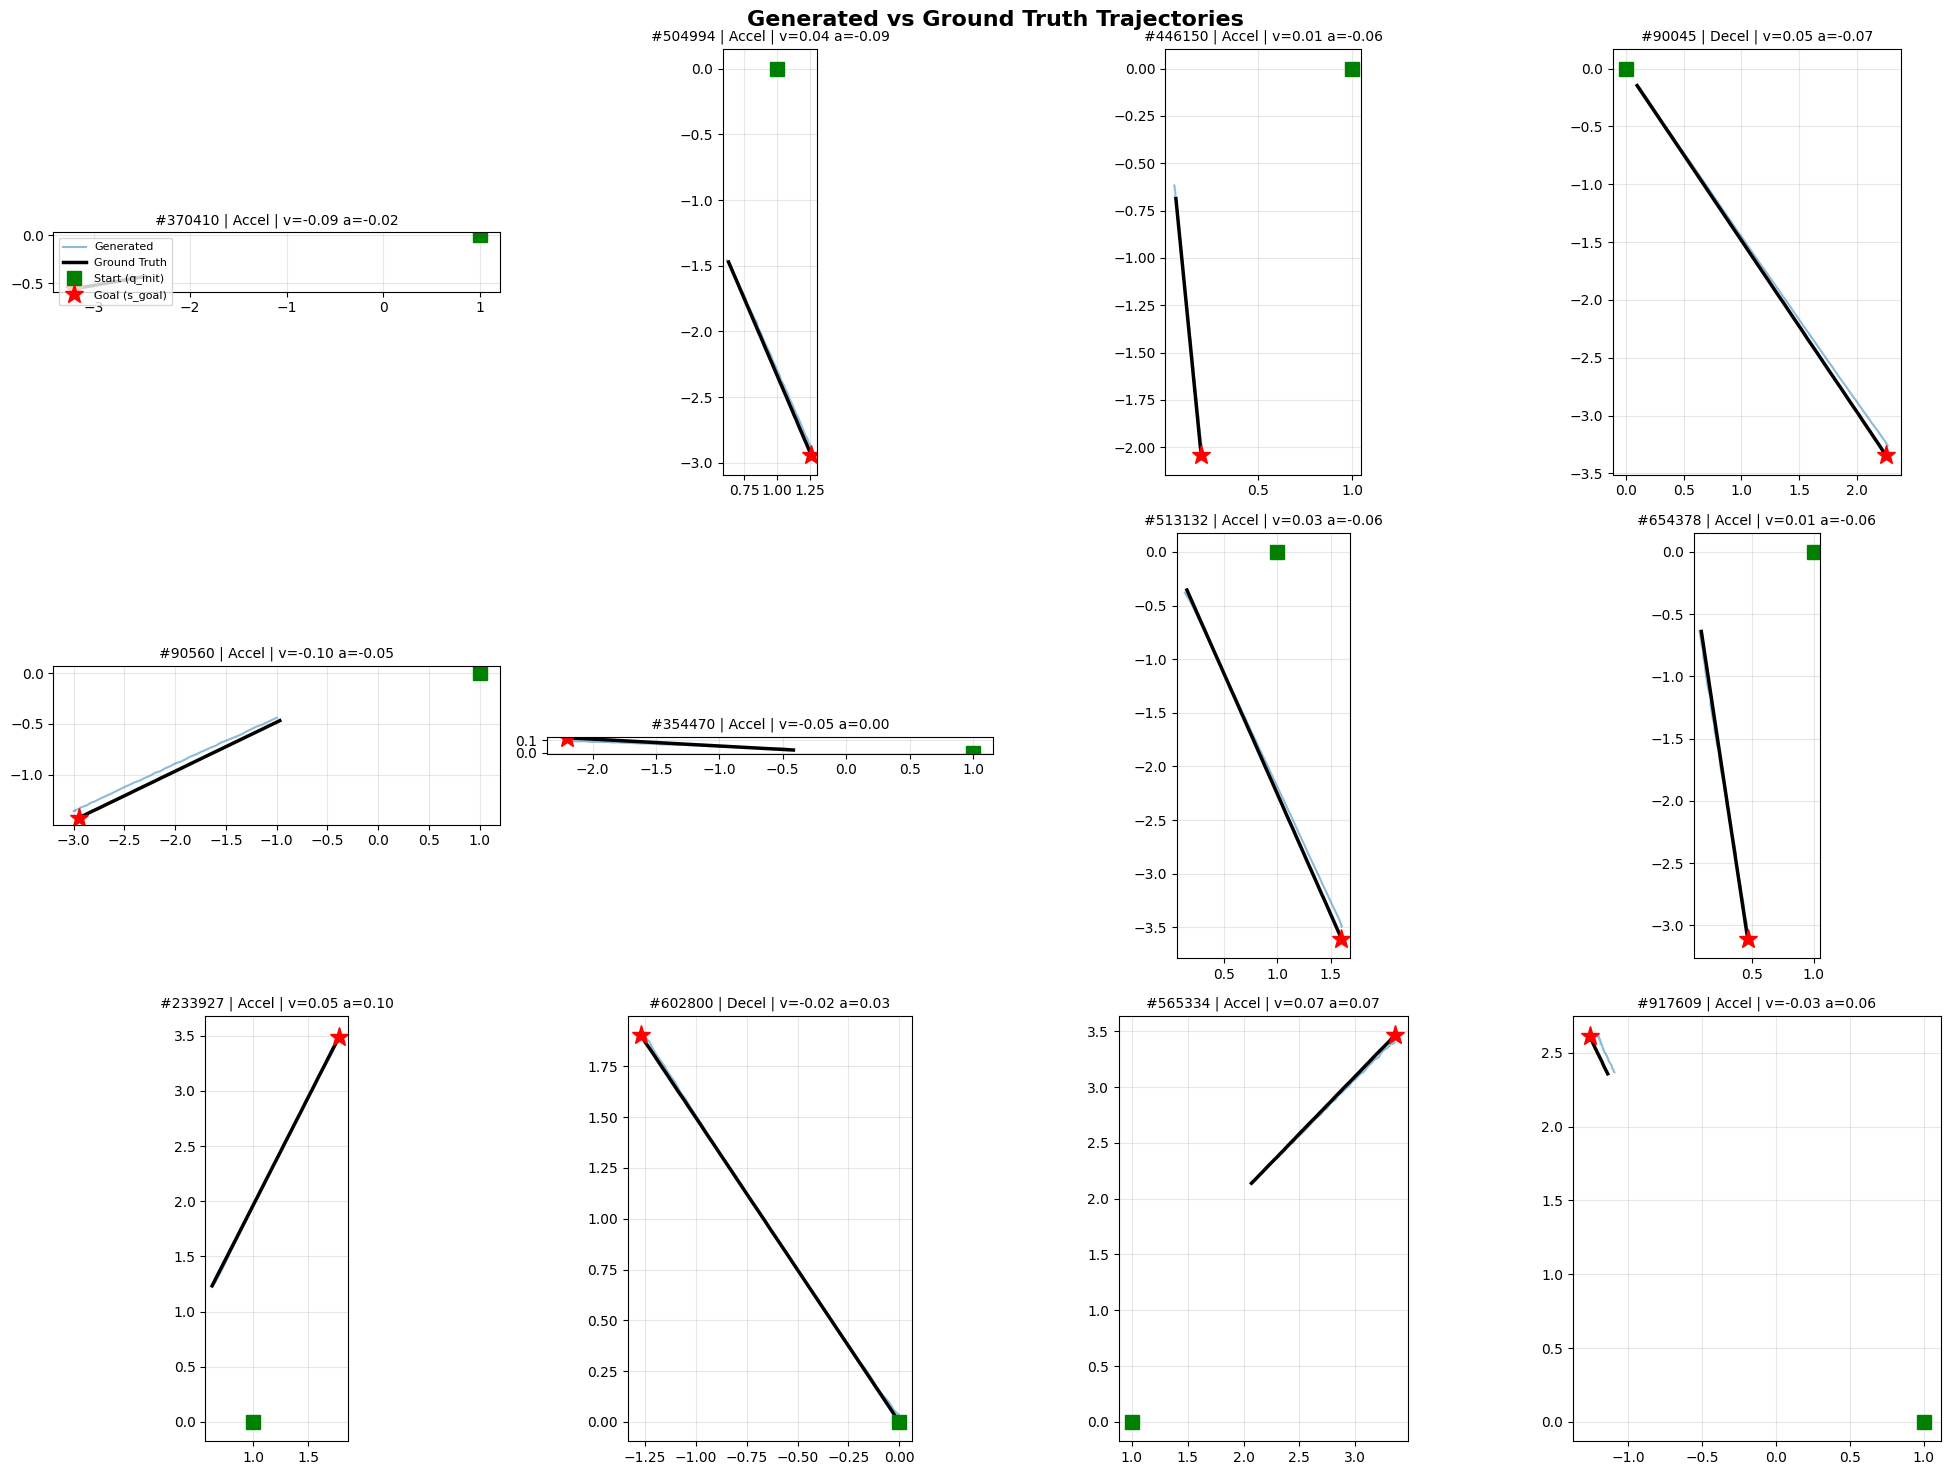

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, ax in enumerate(axes):
    gt = eval_gt[i]  # (50, 2)
    ctx = eval_contexts[i].numpy()
    
    # plot generated samples
    for s in range(N_SAMPLES_PER):
        traj = samples[i, s]  # (50, 2)
        ax.plot(traj[:, 0], traj[:, 1], alpha=0.5, linewidth=1.5, label='Generated' if s == 0 else None)
    
    # plot ground truth
    ax.plot(gt[:, 0], gt[:, 1], 'k-', linewidth=2.5, label='Ground Truth')
    
    # mark start and goal
    ax.plot(ctx[7], ctx[8], 'gs', markersize=10, label='Start (q_init)')
    ax.plot(ctx[0], ctx[1], 'r*', markersize=14, label='Goal (s_goal)')
    
    # part label
    part_names = ['Accel', 'Const', 'Decel']
    part_idx = np.argmax(ctx[4:7])
    ax.set_title(f"#{eval_idx[i]} | {part_names[part_idx]} | v={ctx[2]:.2f} a={ctx[3]:.2f}", fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    if i == 0:
        ax.legend(fontsize=8, loc='upper left')

plt.suptitle("Generated vs Ground Truth Trajectories", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6b. Plot: x(t) and y(t) Over Time (GT vs Generated)

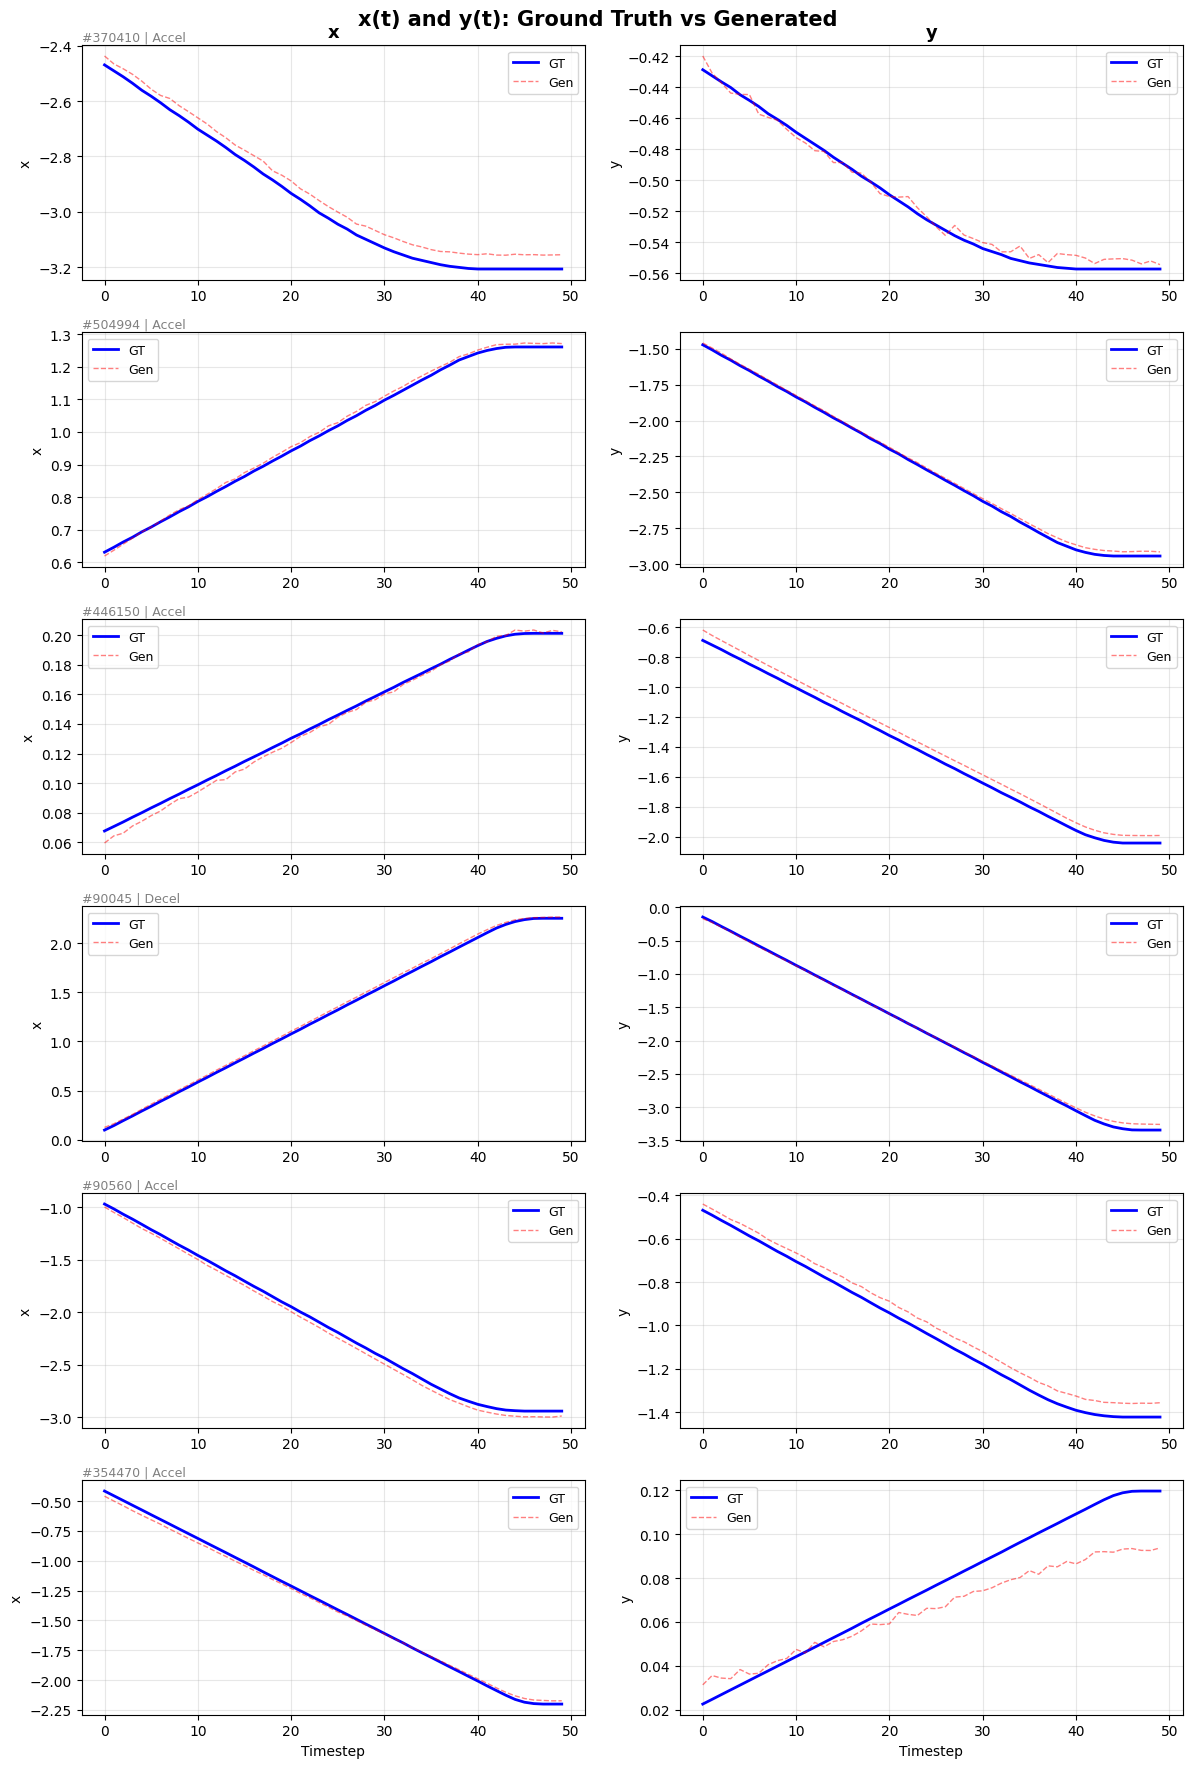

In [10]:
N_SHOW = 6  # number of examples to plot

fig, axes = plt.subplots(N_SHOW, 2, figsize=(12, 3 * N_SHOW))
timesteps = np.arange(ORIGINAL_LEN)

for i in range(N_SHOW):
    gt = eval_gt[i]          # (50, 2)
    gen = samples[i, 0]      # (50, 2) — best or first sample

    # x(t)
    ax_x = axes[i, 0]
    ax_x.plot(timesteps, gt[:, 0], 'b-', linewidth=2, label='GT')
    for s in range(N_SAMPLES_PER):
        ax_x.plot(timesteps, samples[i, s, :, 0], 'r--', linewidth=1, alpha=0.5,
                  label='Gen' if s == 0 else None)
    ax_x.set_ylabel('x')
    ax_x.grid(True, alpha=0.3)
    ax_x.legend(fontsize=9)
    if i == 0:
        ax_x.set_title('x', fontsize=13, fontweight='bold')
    if i == N_SHOW - 1:
        ax_x.set_xlabel('Timestep')

    # y(t)
    ax_y = axes[i, 1]
    ax_y.plot(timesteps, gt[:, 1], 'b-', linewidth=2, label='GT')
    for s in range(N_SAMPLES_PER):
        ax_y.plot(timesteps, samples[i, s, :, 1], 'r--', linewidth=1, alpha=0.5,
                  label='Gen' if s == 0 else None)
    ax_y.set_ylabel('y')
    ax_y.grid(True, alpha=0.3)
    ax_y.legend(fontsize=9)
    if i == 0:
        ax_y.set_title('y', fontsize=13, fontweight='bold')
    if i == N_SHOW - 1:
        ax_y.set_xlabel('Timestep')

    # label each row
    ctx = eval_contexts[i].numpy()
    part_names = ['Accel', 'Const', 'Decel']
    part_idx = np.argmax(ctx[4:7])
    axes[i, 0].annotate(f'#{eval_idx[i]} | {part_names[part_idx]}',
                         xy=(0, 1.02), xycoords='axes fraction', fontsize=9, color='gray')

plt.suptitle('x(t) and y(t): Ground Truth vs Generated', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
#yo

## 7. Plot: ADE Over Prediction Horizon

Shows how error accumulates over time (per-timestep displacement error).

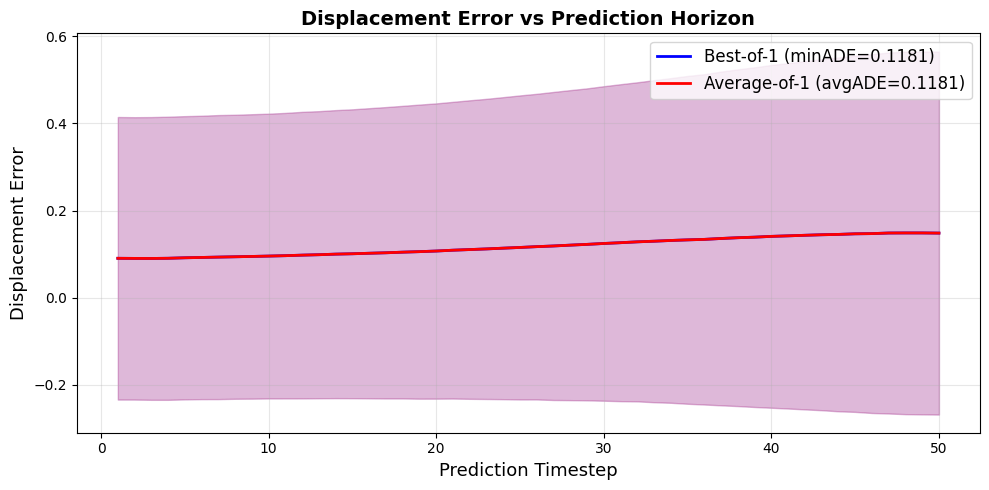

In [11]:
# Per-timestep displacement error: (N_EVAL, N_SAMPLES_PER, 50)
de_per_step = np.sqrt(((samples - eval_gt[:, None, :, :]) ** 2).sum(axis=-1))

# Best-of-N: pick the sample with lowest ADE for each context
best_idx = ade_per_sample.argmin(axis=1)  # (N_EVAL,)
de_best = de_per_step[np.arange(N_EVAL), best_idx, :]  # (N_EVAL, 50)Average
de_avg = de_per_step.mean(axis=1)  # (N_EVAL, 50)

fig, ax = plt.subplots(figsize=(10, 5))
timesteps = np.arange(1, ORIGINAL_LEN + 1)

mean_best = de_best.mean(axis=0)
std_best = de_best.std(axis=0)
mean_avg = de_avg.mean(axis=0)
std_avg = de_avg.std(axis=0)

ax.plot(timesteps, mean_best, 'b-', linewidth=2, label=f'Best-of-{N_SAMPLES_PER} (minADE={mean_best.mean():.4f})')
ax.fill_between(timesteps, mean_best - std_best, mean_best + std_best, alpha=0.15, color='b')

ax.plot(timesteps, mean_avg, 'r-', linewidth=2, label=f'Average-of-{N_SAMPLES_PER} (avgADE={mean_avg.mean():.4f})')
ax.fill_between(timesteps, mean_avg - std_avg, mean_avg + std_avg, alpha=0.15, color='r')

ax.set_xlabel("Prediction Timestep", fontsize=13)
ax.set_ylabel("Displacement Error", fontsize=13)
ax.set_title("Displacement Error vs Prediction Horizon", fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Plot: ADE Distribution & Per-Part Breakdown

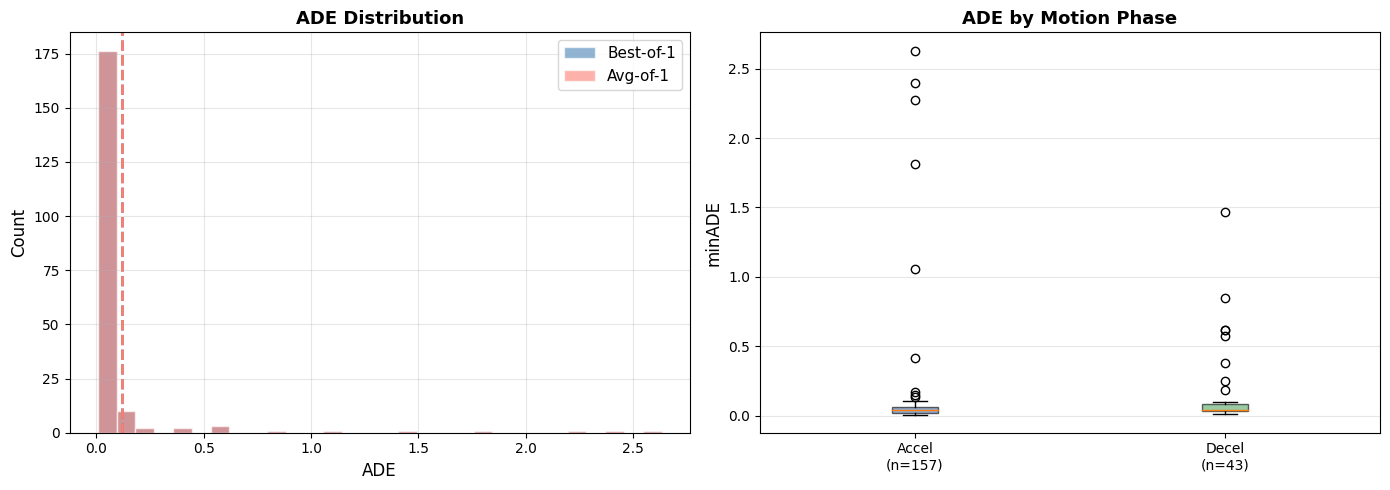

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: ADE histogram ---
ax1.hist(ade_min, bins=30, alpha=0.6, label=f'Best-of-{N_SAMPLES_PER}', color='steelblue', edgecolor='white')
ax1.hist(ade_mean, bins=30, alpha=0.6, label=f'Avg-of-{N_SAMPLES_PER}', color='salmon', edgecolor='white')
ax1.axvline(ade_min.mean(), color='steelblue', linestyle='--', linewidth=2)
ax1.axvline(ade_mean.mean(), color='salmon', linestyle='--', linewidth=2)
ax1.set_xlabel("ADE", fontsize=12)
ax1.set_ylabel("Count", fontsize=12)
ax1.set_title("ADE Distribution", fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# --- Right: ADE per motion part (Accel / Const / Decel) ---
part_names = ['Accel', 'Const', 'Decel']
eval_ctx_np = eval_contexts.numpy()
part_labels = np.argmax(eval_ctx_np[:, 4:7], axis=1)  # 0, 1, or 2

ade_by_part = {name: ade_min[part_labels == i] for i, name in enumerate(part_names)}
bp = ax2.boxplot(
    [ade_by_part[name] for name in part_names if len(ade_by_part[name]) > 0],
    labels=[f"{name}\n(n={len(ade_by_part[name])})" for name in part_names if len(ade_by_part[name]) > 0],
    patch_artist=True,
)
colors = ['#4C72B0', '#55A868', '#C44E52']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.set_ylabel("minADE", fontsize=12)
ax2.set_title("ADE by Motion Phase", fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Plot: Multimodality Check

For a single context, generate many samples to see if the model captures diverse trajectories.

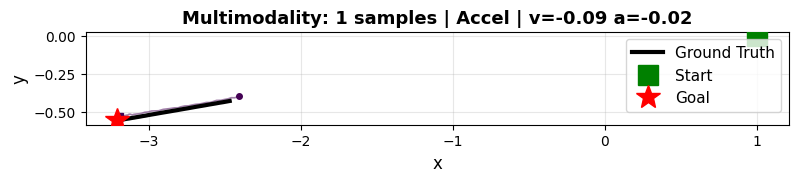

In [13]:
N_MULTI = 1  # generate 1 sample for a single context
pick = 0      # which eval sample to use

single_ctx = eval_contexts[pick:pick+1]
multi_samples, _ = sample_trajectories(diffusion, single_ctx, n_samples_per=N_MULTI)
# multi_samples: (N_MULTI, 50, 2)

fig, ax = plt.subplots(figsize=(8, 8))
cmap = plt.cm.viridis

for s in range(N_MULTI):
    traj = multi_samples[s]
    color = cmap(s / N_MULTI)
    ax.plot(traj[:, 0], traj[:, 1], alpha=0.5, linewidth=1.2, color=color)
    ax.plot(traj[0, 0], traj[0, 1], 'o', color=color, markersize=4)
    ax.plot(traj[-1, 0], traj[-1, 1], 's', color=color, markersize=4)

# Ground truth
gt = eval_gt[pick]
ax.plot(gt[:, 0], gt[:, 1], 'k-', linewidth=3, label='Ground Truth')

ctx = single_ctx.numpy()[0]
ax.plot(ctx[7], ctx[8], 'gs', markersize=14, zorder=5, label='Start')
ax.plot(ctx[0], ctx[1], 'r*', markersize=18, zorder=5, label='Goal')

part_names = ['Accel', 'Const', 'Decel']
part_idx = np.argmax(ctx[4:7])
ax.set_title(f"Multimodality: {N_MULTI} samples | {part_names[part_idx]} | v={ctx[2]:.2f} a={ctx[3]:.2f}",
             fontsize=13, fontweight='bold')
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y", fontsize=12)
ax.set_aspect('equal')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Plot: Sampling Speed vs Quality (N steps)

Test how many Euler steps are needed for good quality (like Fig. 4b in the paper).

  N=  1 steps | ADE=0.1234 | Time=0.02s
  N=  2 steps | ADE=0.0893 | Time=0.01s
  N=  5 steps | ADE=0.0907 | Time=0.02s
  N= 10 steps | ADE=0.0905 | Time=0.03s
  N= 25 steps | ADE=0.0843 | Time=0.08s
  N= 50 steps | ADE=0.1116 | Time=0.16s
  N=100 steps | ADE=0.1155 | Time=0.33s


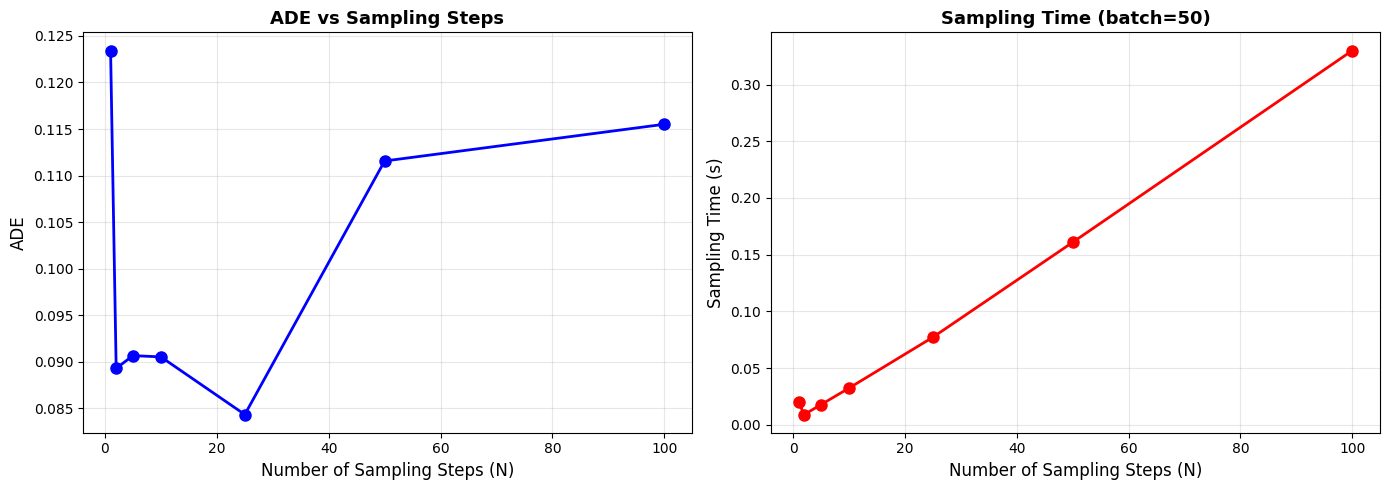

In [14]:
import time

step_counts = [1, 2, 5, 10, 25, 50, 100]
ade_by_steps = []
times_by_steps = []

# Use a small batch for speed test
speed_ctx = eval_contexts[:50]
speed_gt = eval_gt[:50]

for n_steps in step_counts:
    diffusion.set_sampling_timesteps(n_steps)
    
    t0 = time.time()
    samp, _ = sample_trajectories(diffusion, speed_ctx, n_samples_per=1)
    elapsed = time.time() - t0
    
    ade = np.sqrt(((samp - speed_gt) ** 2).sum(axis=-1)).mean()
    ade_by_steps.append(ade)
    times_by_steps.append(elapsed)
    print(f"  N={n_steps:>3d} steps | ADE={ade:.4f} | Time={elapsed:.2f}s")

# Reset to default
diffusion.set_sampling_timesteps(N_SAMPLING_STEPS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(step_counts, ade_by_steps, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel("Number of Sampling Steps (N)", fontsize=12)
ax1.set_ylabel("ADE", fontsize=12)
ax1.set_title("ADE vs Sampling Steps", fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(step_counts, times_by_steps, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel("Number of Sampling Steps (N)", fontsize=12)
ax2.set_ylabel("Sampling Time (s)", fontsize=12)
ax2.set_title(f"Sampling Time (batch={len(speed_ctx)})", fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Inference: Full Trajectory Conditioning (Inpainting)

given a end pose, can the model generate a trajectory that reaches it? This tests if the model can do inpainting, which is a key feature of T-CFM.

Inpainting test  |  N=50  |  endpoint = GT last pose
Metric                          Inpainted       Free  Δ improvement
-------------------------------------------------------------------
FDE (endpoint error)               0.0000     0.2675        +0.2675
ADE (full trajectory)              0.1310     0.2452        +0.1142


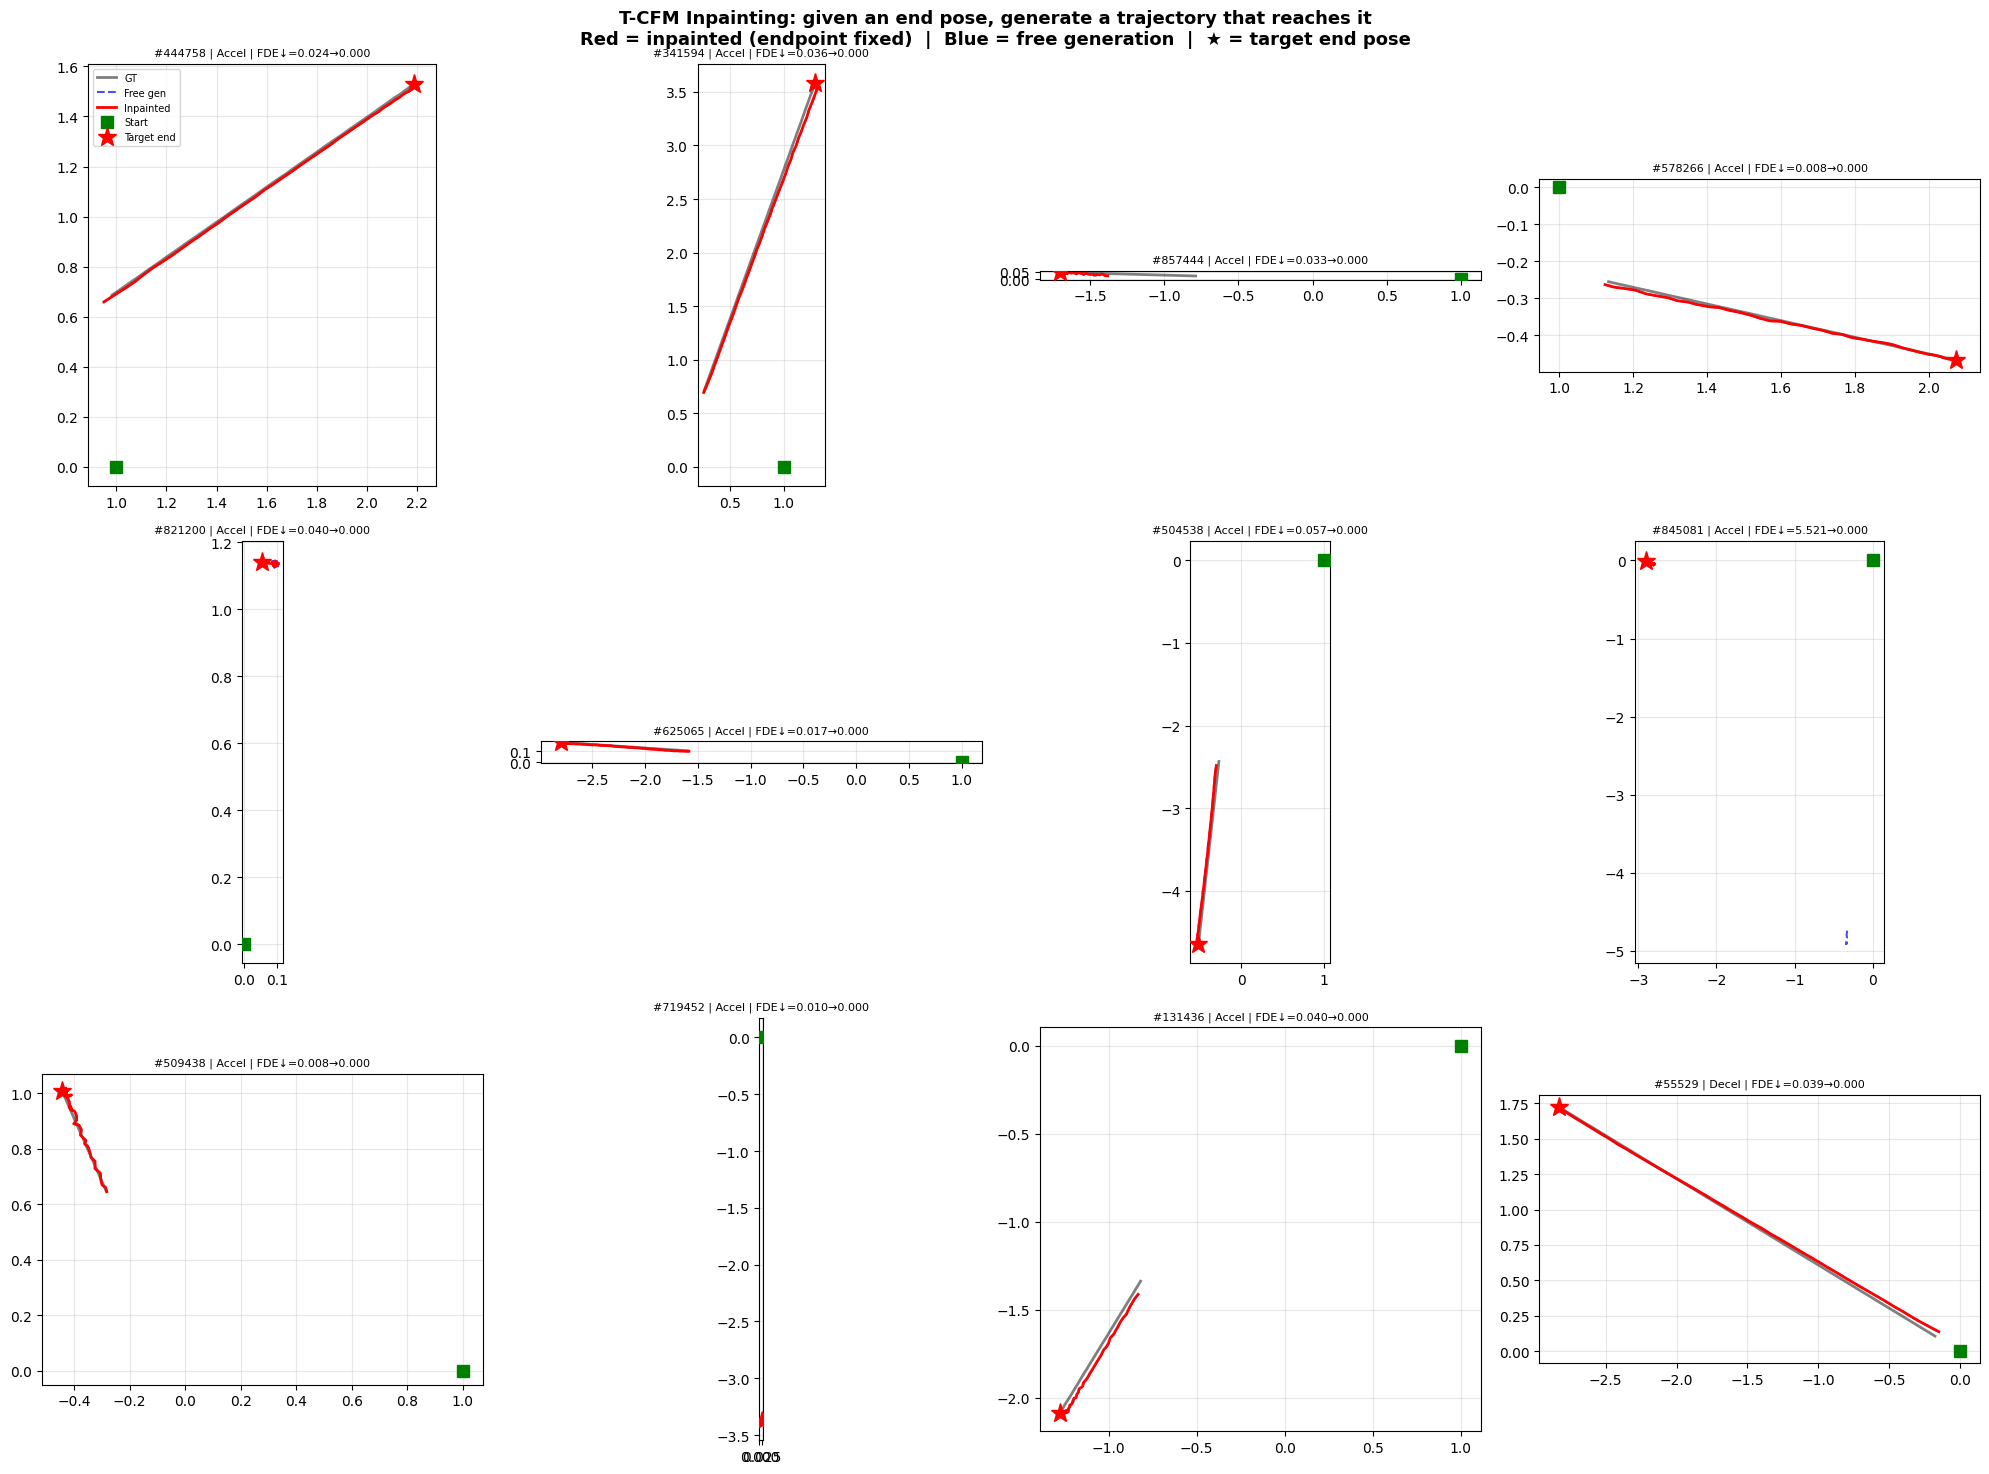

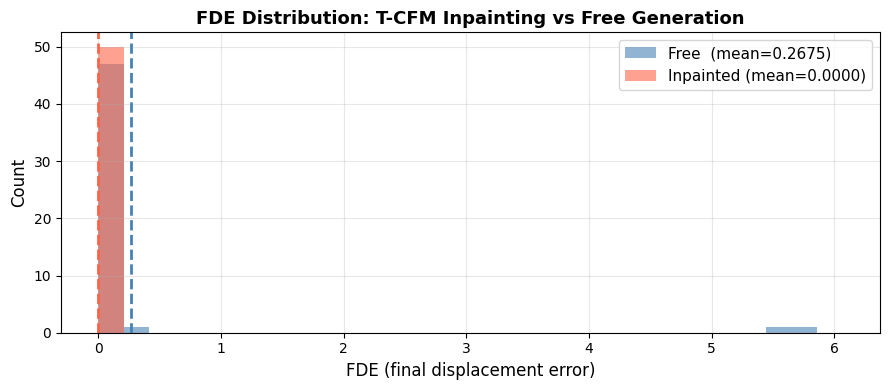


── Counterfactual: target = a *different* sample's end pose ──
FDE to alternative target endpoint: 0.0000 ± 0.0000
(compare: free generation FDE to GT end: 0.2675)


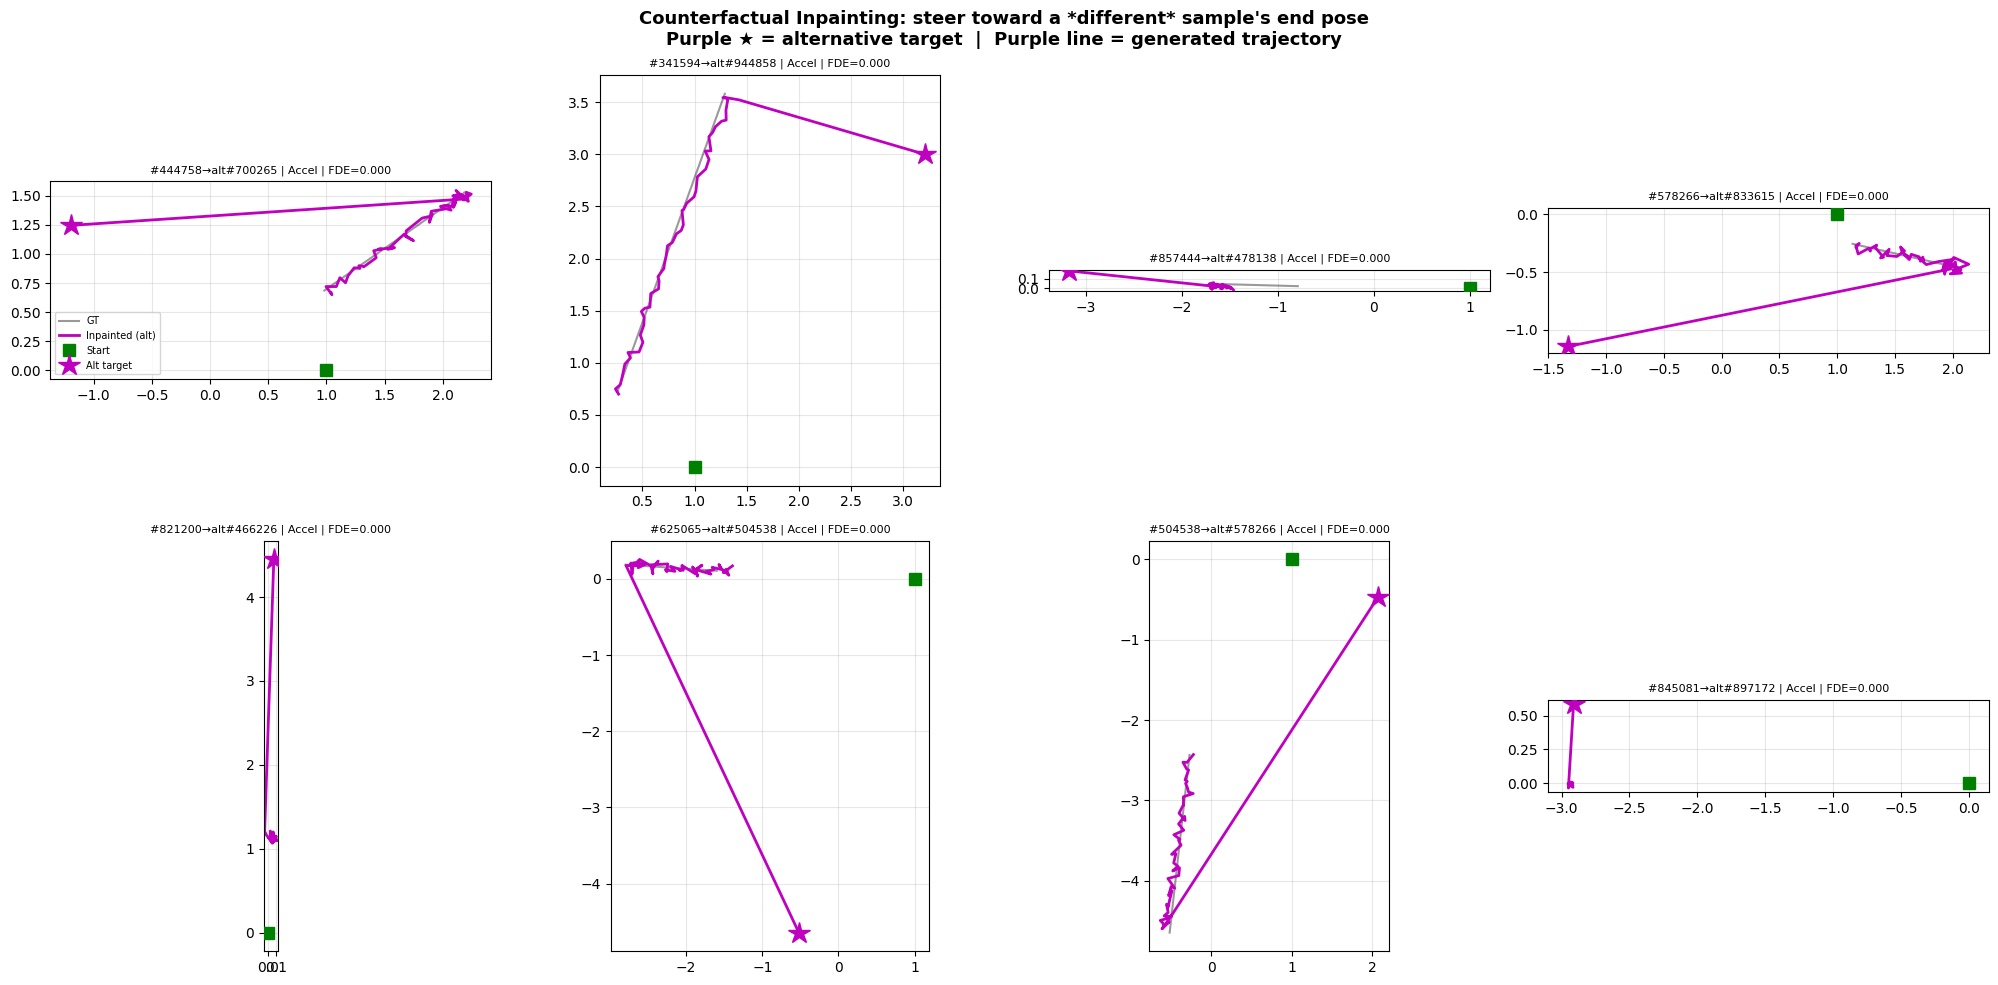

In [15]:
import torchdiffeq

N_INP_EVAL = 50

# ── Inpainting sampler ────────────────────────────────────────────────────────
# T-CFM inpainting: at flow time t ∈ [0,1], the optimal path for a known
# endpoint x_1[-1] = end_pose is:
#   x_t[-1] = (1 - t) * x_0[-1]  +  t * end_pose
# We enforce this at every Euler step so the ODE "steers" toward the target.

@torch.no_grad()
def sample_with_endpoint_inpainting(diffusion, contexts, end_poses):
    """
    Generate trajectories that end at a prescribed end pose using T-CFM inpainting.

    At each Euler step the last trajectory timestep is projected onto the
    optimal-transport path from initial noise to `end_poses`:
        x_t[-1] = (1 - t) * x0_last  +  t * end_pose

    Args:
        contexts  : (B, context_dim) float32 tensor
        end_poses : (B, 2)           float32 tensor  – target (x, y) at step ORIGINAL_LEN-1

    Returns:
        samples_inp : (B, ORIGINAL_LEN, 2) numpy – inpainted (endpoint fixed)
        samples_free: (B, ORIGINAL_LEN, 2) numpy – free generation (no endpoint fix)
    """
    diffusion.eval()
    ctx       = contexts.to(DEVICE)
    end_poses = end_poses.to(DEVICE)          # (B, 2)
    B         = ctx.shape[0]

    global_cond = {'hideouts': ctx}
    shape = (B, HORIZON, 2)

    # ── shared noise initialisation ──
    x0 = torch.randn(shape, device=DEVICE)
    x0_last = x0[:, ORIGINAL_LEN - 1, :].clone()   # noise at the endpoint slot

    t_span = torch.linspace(0, 1, N_SAMPLING_STEPS + 1, device=DEVICE)

    # ── inpainted Euler integration ──
    x_inp = x0.clone()
    for i in range(N_SAMPLING_STEPS):
        t      = t_span[i]
        t_next = t_span[i + 1]
        dt     = t_next - t

        vt     = diffusion.model.forward(t, x_inp, global_cond=global_cond)
        x_inp  = x_inp + vt * dt

        # project endpoint onto OT path → x_t[-1] = (1-t)*x0_last + t*end_pose
        x_inp[:, ORIGINAL_LEN - 1, :] = (1 - t_next) * x0_last + t_next * end_poses

    # ── free Euler integration (same noise, no projection) ──
    x_free = x0.clone()
    for i in range(N_SAMPLING_STEPS):
        t      = t_span[i]
        t_next = t_span[i + 1]
        dt     = t_next - t
        vt     = diffusion.model.forward(t, x_free, global_cond=global_cond)
        x_free = x_free + vt * dt

    samples_inp  = x_inp.cpu().numpy()[:, :ORIGINAL_LEN, :]
    samples_free = x_free.cpu().numpy()[:, :ORIGINAL_LEN, :]
    return samples_inp, samples_free


# ── select test samples ───────────────────────────────────────────────────────
rng_inp  = np.random.default_rng(7)
inp_idx  = rng_inp.choice(len(context_all), N_INP_EVAL, replace=False)

inp_contexts = context_all[inp_idx]           # (N, context_dim)
inp_gt       = A_gt[inp_idx]                  # (N, 50, 2)

# target end pose = ground-truth last position
target_end   = torch.tensor(inp_gt[:, -1, :], dtype=torch.float32)   # (N, 2)

samples_inp, samples_free = sample_with_endpoint_inpainting(
    diffusion, inp_contexts, target_end
)

# ── metrics ───────────────────────────────────────────────────────────────────
def fde(pred, gt): return np.sqrt(((pred[:, -1, :] - gt[:, -1, :]) ** 2).sum(-1))
def ade(pred, gt): return np.sqrt(((pred - gt) ** 2).sum(-1)).mean(-1)

fde_inp  = fde(samples_inp,  inp_gt)
fde_free = fde(samples_free, inp_gt)
ade_inp  = ade(samples_inp,  inp_gt)
ade_free = ade(samples_free, inp_gt)

print(f"Inpainting test  |  N={N_INP_EVAL}  |  endpoint = GT last pose")
print(f"{'Metric':<30} {'Inpainted':>10} {'Free':>10} {'Δ improvement':>14}")
print("-" * 67)
print(f"{'FDE (endpoint error)':<30} {fde_inp.mean():>10.4f} {fde_free.mean():>10.4f} "
      f"{(fde_free.mean() - fde_inp.mean()):>+14.4f}")
print(f"{'ADE (full trajectory)':<30} {ade_inp.mean():>10.4f} {ade_free.mean():>10.4f} "
      f"{(ade_free.mean() - ade_inp.mean()):>+14.4f}")


# ── plot: trajectory comparison ───────────────────────────────────────────────
N_SHOW = min(12, N_INP_EVAL)
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= N_SHOW:
        ax.axis('off')
        continue

    gt     = inp_gt[i]
    gen_i  = samples_inp[i]
    gen_f  = samples_free[i]
    ctx    = inp_contexts[i].numpy()
    t_end  = target_end[i].numpy()

    ax.plot(gt[:, 0],    gt[:, 1],    'k-',  linewidth=2,   alpha=0.5, label='GT')
    ax.plot(gen_f[:, 0], gen_f[:, 1], 'b--', linewidth=1.5, alpha=0.7, label='Free gen')
    ax.plot(gen_i[:, 0], gen_i[:, 1], 'r-',  linewidth=2,              label='Inpainted')

    # start & target end pose
    ax.plot(ctx[7], ctx[8], 'gs',  markersize=9,  zorder=5, label='Start')
    ax.plot(t_end[0], t_end[1], 'r*', markersize=14, zorder=6, label='Target end')

    part_names = ['Accel', 'Const', 'Decel']
    part_idx   = np.argmax(ctx[4:7])
    ax.set_title(
        f"#{inp_idx[i]} | {part_names[part_idx]} | "
        f"FDE↓={fde_free[i]:.3f}→{fde_inp[i]:.3f}",
        fontsize=8
    )
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7, loc='upper left')

plt.suptitle(
    "T-CFM Inpainting: given an end pose, generate a trajectory that reaches it\n"
    "Red = inpainted (endpoint fixed)  |  Blue = free generation  |  ★ = target end pose",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


# ── FDE distribution: inpainted vs free ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, max(fde_free.max(), fde_inp.max()) * 1.05, 30)
ax.hist(fde_free, bins=bins, alpha=0.6, color='steelblue', label=f'Free  (mean={fde_free.mean():.4f})')
ax.hist(fde_inp,  bins=bins, alpha=0.6, color='tomato',    label=f'Inpainted (mean={fde_inp.mean():.4f})')
ax.axvline(fde_free.mean(), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(fde_inp.mean(),  color='tomato',    linestyle='--', linewidth=2)
ax.set_xlabel("FDE (final displacement error)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("FDE Distribution: T-CFM Inpainting vs Free Generation", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ── counterfactual: steer toward a *different* end pose ──────────────────────
# Pick a random target not from the GT and see if the model still reaches it.
print("\n── Counterfactual: target = a *different* sample's end pose ──")
shift       = rng_inp.integers(1, N_INP_EVAL, size=N_INP_EVAL)
alt_targets = torch.tensor(inp_gt[shift, -1, :], dtype=torch.float32)   # (N, 2)

samples_alt, _ = sample_with_endpoint_inpainting(diffusion, inp_contexts, alt_targets)

# manual FDE to alt target
fde_to_alt = np.sqrt(((samples_alt[:, -1, :] - alt_targets.numpy()) ** 2).sum(-1))
print(f"FDE to alternative target endpoint: {fde_to_alt.mean():.4f} ± {fde_to_alt.std():.4f}")
print(f"(compare: free generation FDE to GT end: {fde_free.mean():.4f})")

# show a few counterfactual examples
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, ax in enumerate(axes):
    if i >= 8:
        break
    gt       = inp_gt[i]
    gen_alt  = samples_alt[i]
    t_alt    = alt_targets[i].numpy()
    ctx      = inp_contexts[i].numpy()

    ax.plot(gt[:, 0],      gt[:, 1],      'k-',  linewidth=1.5, alpha=0.4, label='GT')
    ax.plot(gen_alt[:, 0], gen_alt[:, 1], 'm-',  linewidth=2,              label='Inpainted (alt)')
    ax.plot(ctx[7], ctx[8], 'gs', markersize=9, zorder=5, label='Start')
    ax.plot(t_alt[0], t_alt[1], 'm*', markersize=16, zorder=6, label='Alt target')

    part_names = ['Accel', 'Const', 'Decel']
    part_idx = np.argmax(ctx[4:7])
    ax.set_title(
        f"#{inp_idx[i]}→alt#{inp_idx[shift[i]]} | {part_names[part_idx]} | "
        f"FDE={fde_to_alt[i]:.3f}",
        fontsize=8
    )
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle(
    "Counterfactual Inpainting: steer toward a *different* sample's end pose\n"
    "Purple ★ = alternative target  |  Purple line = generated trajectory",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

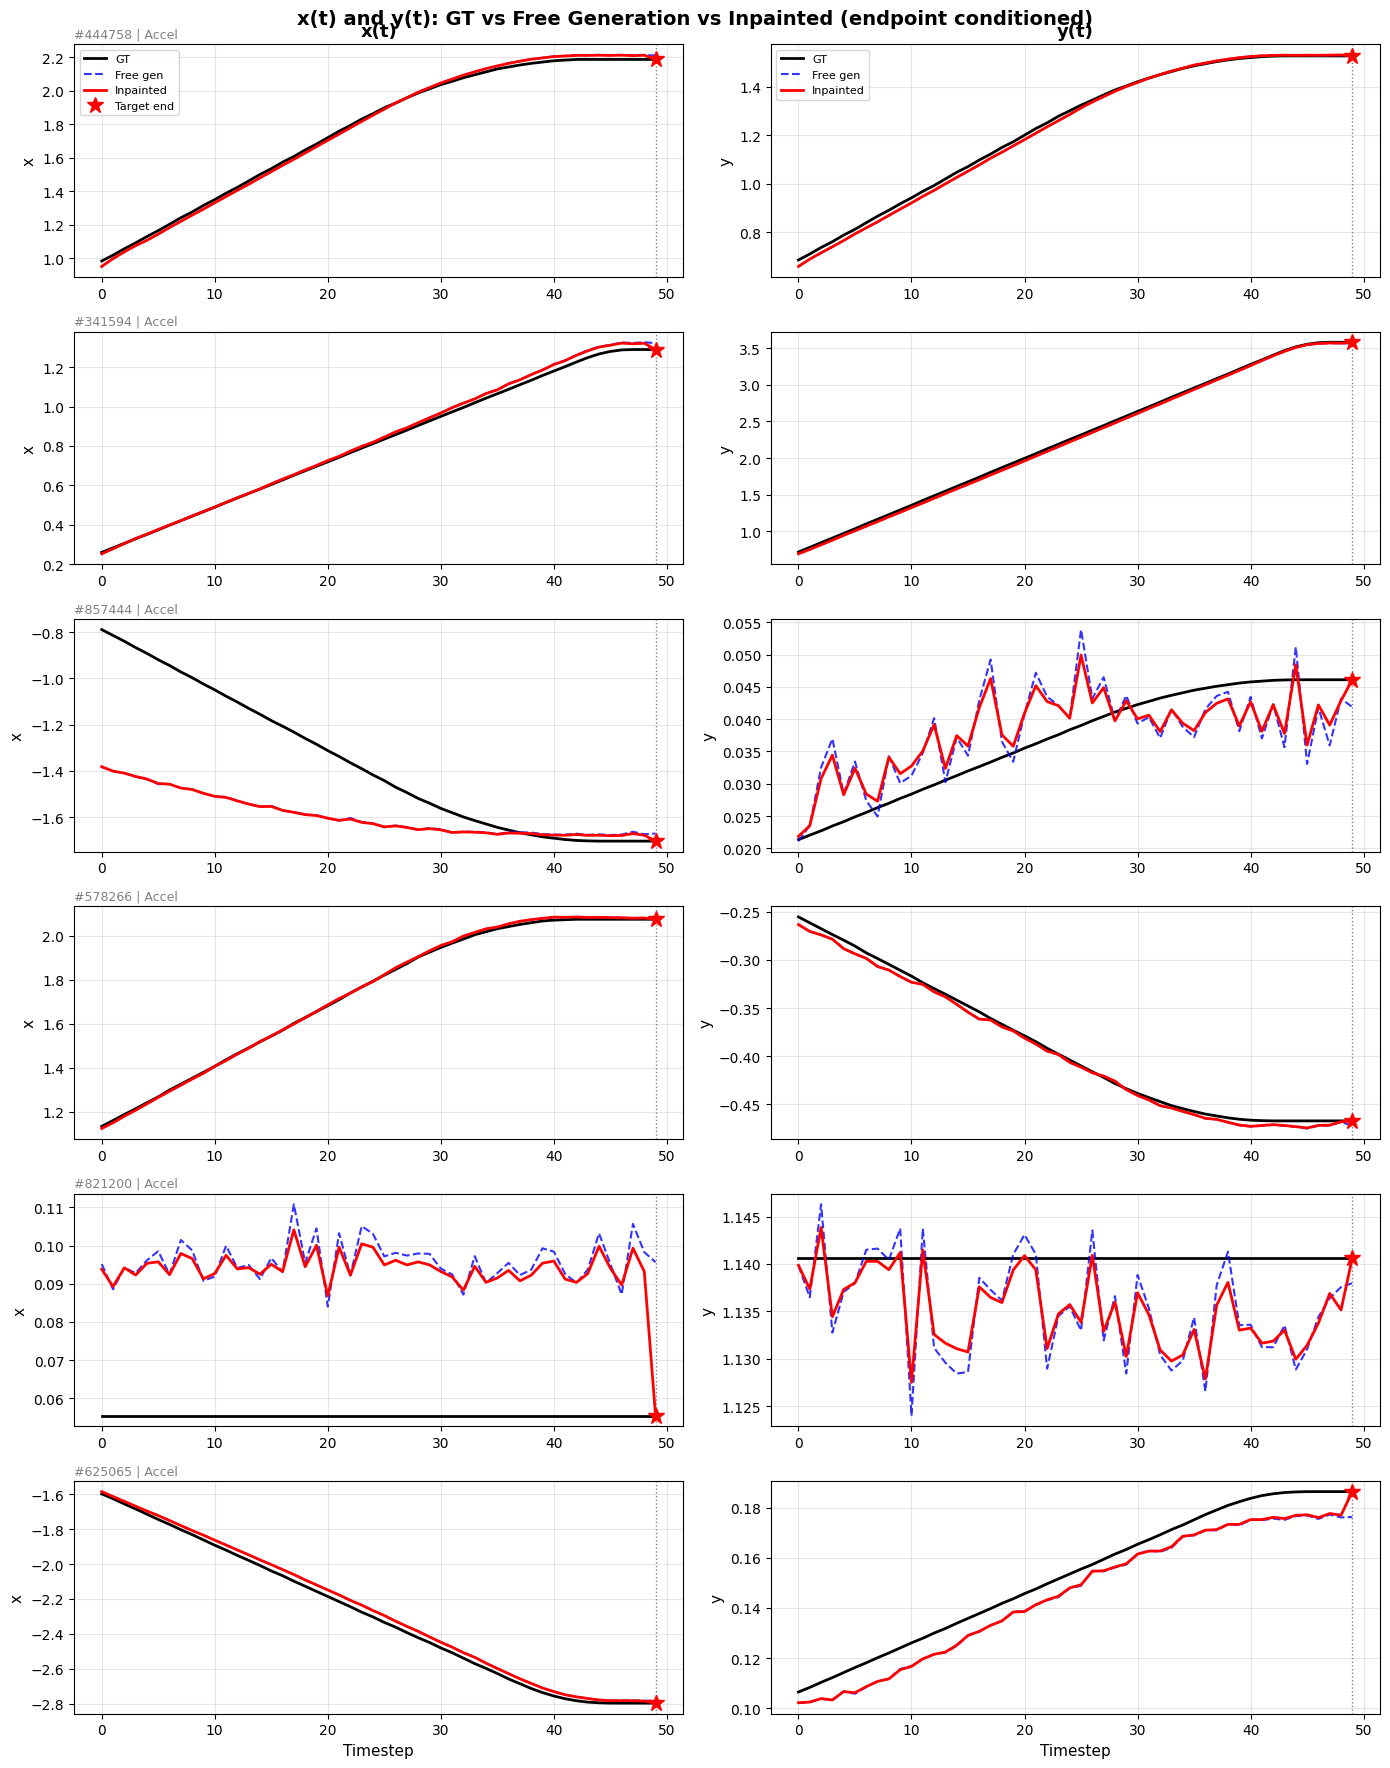

In [16]:
# ── x(t) and y(t) over time: GT vs Free vs Inpainted ────────────────────────
N_SHOW_XT = 6
timesteps  = np.arange(ORIGINAL_LEN)

fig, axes = plt.subplots(N_SHOW_XT, 2, figsize=(14, 3 * N_SHOW_XT))

for i in range(N_SHOW_XT):
    gt    = inp_gt[i]          # (50, 2)
    gen_i = samples_inp[i]     # (50, 2)
    gen_f = samples_free[i]    # (50, 2)
    t_end = target_end[i].numpy()
    ctx   = inp_contexts[i].numpy()

    part_names = ["Accel", "Const", "Decel"]
    part_idx   = np.argmax(ctx[4:7])
    row_label  = f"#{inp_idx[i]} | {part_names[part_idx]}"

    for col, (dim, dim_name) in enumerate([(0, "x"), (1, "y")]):
        ax = axes[i, col]

        ax.plot(timesteps, gt[:, dim],    "k-",  linewidth=2,   label="GT")
        ax.plot(timesteps, gen_f[:, dim], "b--", linewidth=1.5, alpha=0.8, label="Free gen")
        ax.plot(timesteps, gen_i[:, dim], "r-",  linewidth=2,   label="Inpainted")

        # mark target endpoint
        ax.axvline(ORIGINAL_LEN - 1, color="gray", linestyle=":", linewidth=1)
        ax.plot(ORIGINAL_LEN - 1, t_end[dim], "r*", markersize=12, zorder=5,
                label="Target end" if (i == 0 and col == 0) else None)

        ax.set_ylabel(dim_name, fontsize=11)
        ax.grid(True, alpha=0.3)

        if i == 0:
            ax.set_title(f"{dim_name}(t)", fontsize=13, fontweight="bold")
            ax.legend(fontsize=8, loc="upper left")
        if i == N_SHOW_XT - 1:
            ax.set_xlabel("Timestep", fontsize=11)

    axes[i, 0].annotate(row_label, xy=(0, 1.03), xycoords="axes fraction",
                        fontsize=9, color="gray")

plt.suptitle("x(t) and y(t): GT vs Free Generation vs Inpainted (endpoint conditioned)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 12 Conclusion

In [17]:
@torch.no_grad()
def sample_trajectories(diffusion, contexts, n_samples_per=1):
    """
    Generate trajectories for given context vectors.
    
    Args:
        diffusion: trained CFM model
        contexts: (B, 9) context tensor
        n_samples_per: how many samples to generate per context
    Returns:
        samples: (B * n_samples_per, ORIGINAL_LEN, 2) numpy array
        contexts_repeated: (B * n_samples_per, 9) numpy array
    """
    diffusion.eval()
    
    # repeat contexts for multiple samples
    ctx = contexts.repeat_interleave(n_samples_per, dim=0).to(DEVICE)
    batch_size = ctx.shape[0]
    
    global_cond = {'hideouts': ctx}
    cond = [(np.array([]), np.array([]))] * batch_size
    
    samples = diffusion.conditional_sample(global_cond, cond)  # (B*n, HORIZON, 2)
    samples = samples.cpu().numpy()
    
    # trim padding back to original 50 steps
    samples = samples[:, :ORIGINAL_LEN, :]
    contexts_out = ctx.cpu().numpy()
    
    return samples, contexts_out

print("Sampling helper ready.")

Sampling helper ready.


In [18]:
data = np.load(DATA_PATH) # load dataset (limit to 1M samples for memory)
df = pd.DataFrame(data['features'], columns=data['feature_names'])[:1000000] 
df['targets'] = [t for t in data['targets'][:1000000]]

# Context vector C (9-dim)
part_onehot = pd.get_dummies(df['part_enum'].astype(int), prefix='part').values
C = np.concatenate([
    df[['s_goal_x', 's_goal_y', 's_goal_z', 'q_init_z', 'v_const', 'accel']].values,
    part_onehot,
    df[['q_init_x', 'q_init_y']].values
], axis=1)

# Ground truth trajectories (x, y)
targets_raw = np.stack(df['targets'].values)
A_gt = targets_raw[:, :, 0:2]  # (N, 50, 2)

context_all = torch.tensor(C, dtype=torch.float32)
print(f"Dataset: {len(df)} samples, context_dim={C.shape[1]}, trajectory=({A_gt.shape[1]}, {A_gt.shape[2]})")

Dataset: 1000000 samples, context_dim=12, trajectory=(50, 2)


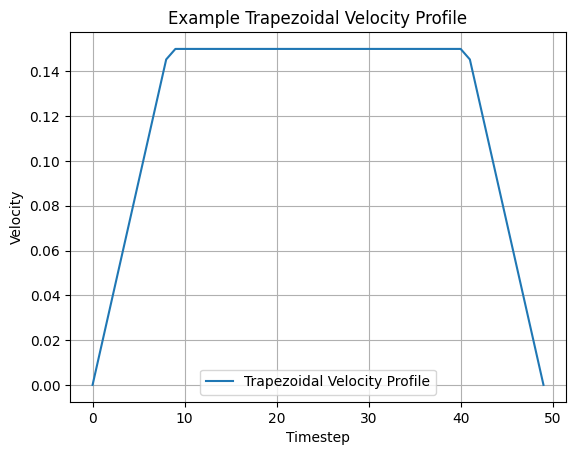

Generated samples shape: (200, 50, 2)


In [19]:
# Let goal x,y in this range
# displacement_range: tuple[float, float] = (1.0, 5.0)
# # 0.1 - 0.2 m/s
# v_max_range: tuple[float, float] = (0.1, 0.2)
# # 0.02 - 0.04
# a_max_range: tuple[float, float] = (0.02, 0.04)

def trapezoidal_profile(v_max, a_max, total_dist, n_steps=50):
    """
    Generate a trapezoidal velocity profile for a given distance and constraints.
    
    Args:
        v_max: maximum velocity
        a_max: maximum acceleration
        total_dist: total distance to cover
        n_steps: number of timesteps in the trajectory
    Returns:
        profile: (n_steps,) velocity profile over time
    """
    t_accel = v_max / a_max
    d_accel = 0.5 * a_max * t_accel**2
    
    if 2 * d_accel >= total_dist:
        # Triangular profile (never reaches v_max)
        t_accel = np.sqrt(total_dist / a_max)
        t_const = 0
    else:
        # Trapezoidal profile
        t_const = (total_dist - 2 * d_accel) / v_max
    
    total_time = 2 * t_accel + t_const
    time_steps = np.linspace(0, total_time, n_steps)
    
    profile = np.zeros_like(time_steps)
    for i, t in enumerate(time_steps):
        if t < t_accel:
            profile[i] = a_max * t
        elif t < t_accel + t_const:
            profile[i] = v_max
        else:
            profile[i] = max(0, v_max - a_max * (t - t_accel - t_const))
    
    return profile

gt = trapezoidal_profile(v_max=0.15, a_max=0.037, total_dist=3.0)
plt.plot(gt, label='Trapezoidal Velocity Profile')
plt.xlabel('Timestep')
plt.ylabel('Velocity')
plt.title('Example Trapezoidal Velocity Profile')
plt.grid(True)
plt.legend()
plt.show()

N_SAMPLES_PER = 1     # how many trajectories to sample per context
# create initial context for testing
# remind myself that :
# s_goal_z = qdot_x
# q_init_z = qdot_y
context = pd.DataFrame({'s_goal_x': [3],
                        's_goal_y': [3],
                        's_goal_z': [0],
                        'q_init_z': [0],
                        'v_const': [0.15],
                        'accel': [0.037],
                        'part_enum': [0],
                        'q_init_x': [0],
                        'q_init_y': [0]})
# Generate
samples, _ = sample_trajectories(diffusion, eval_contexts, n_samples_per=N_SAMPLES_PER)
print(f"Generated samples shape: {samples.shape}")

In [20]:
# # Pick test samples to evaluate
# N_EVAL = 200          # how many test contexts to use
# # N_SAMPLES_PER = 5     # how many trajectories to sample per context
# N_SAMPLES_PER = 1     # how many trajectories to sample per context

# rng = np.random.default_rng(42)
# eval_idx = rng.choice(len(context_all), N_EVAL, replace=False)

eval_contexts = context_all[eval_idx]
eval_gt = A_gt[eval_idx]  # (N_EVAL, 50, 2)

# Generate
samples, _ = sample_trajectories(diffusion, eval_contexts, n_samples_per=N_SAMPLES_PER)
# samples = samples.reshape(N_EVAL, N_SAMPLES_PER, ORIGINAL_LEN, 2)